# 1 · Translation — Text Preprocessing

1. Load raw CSV from `datasets/translation/`
2. Clean text (lowercase, remove special characters)
3. Add `<start>` / `<end>` tokens to target sentences
4. Split into train / test sets
5. Fit Keras Tokenisers **on training data only**
6. Convert sentences to zero-padded integer sequences
7. Save tokenisers → `models/translation/`
8. Save padded arrays (artifacts) → `artifacts/translation/`

## 0 · Configuration
Change `LANGUAGE` to preprocess a different language pair.

In [2]:
import sys, os
# Add project root to path so src.* imports work from the notebook
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ── USER SETTING ──────────────────────────────────────────────────────────────
LANGUAGE  = 'french'   # Change to: 'french' | 'spanish' | 'german' | 'hindi'
NROWS     = None       # Set to an integer (e.g. 50000) to limit rows for testing
TEST_SIZE = 0.2      # Fraction of data held out for evaluation
# ─────────────────────────────────────────────────────────────────────────────

print(f'Language: {LANGUAGE.upper()}')

Language: FRENCH


## 1 · Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    TRANSLATION_DATASET_DIR,
    LANGUAGE_CSV_MAP, LANGUAGE_COL_MAP,
    TRANS_ENG_VOCAB_SIZE, TRANS_TARGET_VOCAB_SIZE,
    TRANS_MAX_ENG_LEN, TRANS_MAX_TARGET_LEN,
    get_eng_tokenizer_path, get_target_tokenizer_path,
    get_translation_artifact_path,
)
from src.common import set_seed, ensure_dirs
from src.translation.dataset import load_raw_data, prepare_translation_dataset
from src.translation.preprocessing import clean_text

set_seed(42)
print('Imports successful.')

Imports successful.


## 2 · Load Raw Data

In [4]:
df = load_raw_data(LANGUAGE, nrows=NROWS)
print(f'\nDataset shape: {df.shape}')
df.head(5)

[INFO] Loaded 239,597 sentence pairs for English → French

Dataset shape: (239597, 2)


,english,french
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !


## 3 · Explore Sentence Lengths

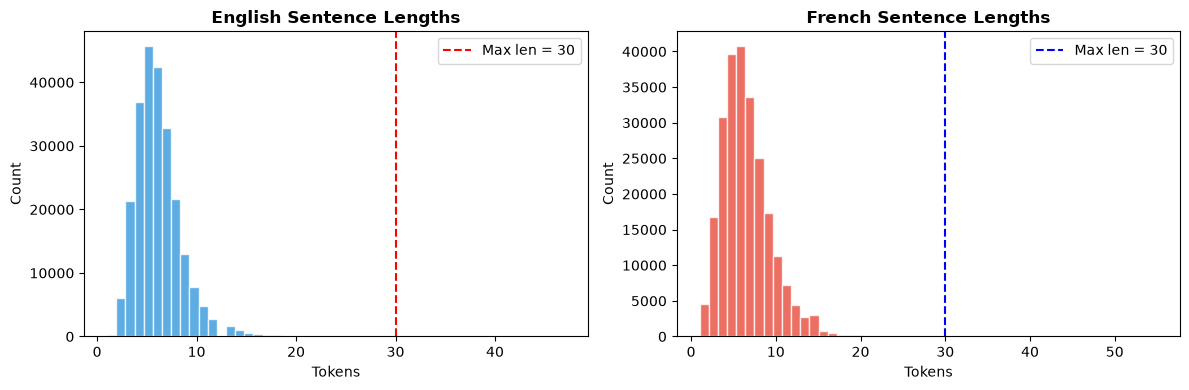

English  → mean: 6.1  median: 6  max: 47
French → mean: 6.6  median: 6  max: 55


In [5]:
target_col = LANGUAGE_COL_MAP[LANGUAGE]

eng_lengths = df['english'].apply(lambda x: len(str(x).split()))
tgt_lengths = df[target_col].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(eng_lengths, bins=50, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].axvline(TRANS_MAX_ENG_LEN, color='red', linestyle='--', label=f'Max len = {TRANS_MAX_ENG_LEN}')
axes[0].set_title('English Sentence Lengths', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tokens'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(tgt_lengths, bins=50, color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].axvline(TRANS_MAX_TARGET_LEN, color='blue', linestyle='--', label=f'Max len = {TRANS_MAX_TARGET_LEN}')
axes[1].set_title(f'{LANGUAGE.capitalize()} Sentence Lengths', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tokens'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f'English  → mean: {eng_lengths.mean():.1f}  median: {eng_lengths.median():.0f}  max: {eng_lengths.max()}')
print(f'{LANGUAGE.capitalize()} → mean: {tgt_lengths.mean():.1f}  median: {tgt_lengths.median():.0f}  max: {tgt_lengths.max()}')

## 4 · Run Full Preprocessing Pipeline

This single call:
- Cleans & tokenises both sides
- Splits train / test
- Builds & saves tokenisers
- Pads & saves artifacts

In [6]:
data = prepare_translation_dataset(
    language  = LANGUAGE,
    test_size = TEST_SIZE,
    nrows     = NROWS,
)

print('\n--- Output Shapes ---')
for key in ['eng_train', 'eng_test', 'tgt_train', 'tgt_test']:
    print(f'  {key:<12}: {data[key].shape}')

[INFO] Loaded 239,597 sentence pairs for English → French
[INFO] Split → Train: 40,000  |  Test: 10,000
[INFO] Tokenizer fitted — vocab size: 8,798 (capped at 15,000)
[INFO] Tokenizer fitted — vocab size: 13,427 (capped at 15,000)
[INFO] Shapes → eng_train: (40000, 30)  tgt_train: (40000, 30)
[INFO] Tokenizer saved  →  c:\Users\himan\Documents\trial 2\models\translation\english_french_tokenizer.pkl
[INFO] Tokenizer saved  →  c:\Users\himan\Documents\trial 2\models\translation\french_tokenizer.pkl
[INFO] Artifacts saved → c:\Users\himan\Documents\trial 2\artifacts\translation\french_train.pkl
[INFO] Artifacts saved → c:\Users\himan\Documents\trial 2\artifacts\translation\french_test.pkl

--- Output Shapes ---
  eng_train   : (40000, 30)
  eng_test    : (10000, 30)
  tgt_train   : (40000, 30)
  tgt_test    : (10000, 30)


## 5 · Vocabulary Statistics

In [7]:
eng_tok = data['eng_tokenizer']
tgt_tok = data['tgt_tokenizer']

print(f'English  vocab size : {len(eng_tok.word_index):,}  (capped at {TRANS_ENG_VOCAB_SIZE:,})')
print(f'{LANGUAGE.capitalize()} vocab size : {len(tgt_tok.word_index):,}  (capped at {TRANS_TARGET_VOCAB_SIZE:,})')

print('\nTop 15 English tokens:')
top_eng = sorted(eng_tok.word_counts.items(), key=lambda x: -x[1])[:15]
for word, count in top_eng:
    print(f'  {word:<20} {count:,}')

English  vocab size : 8,798  (capped at 15,000)
French vocab size : 13,427  (capped at 15,000)

Top 15 English tokens:
  i                    14,263
  you                  11,624
  to                   8,657
  the                  8,100
  a                    5,729
  t                    5,467
  tom                  4,246
  that                 4,216
  is                   3,948
  it                   3,520
  s                    3,146
  do                   2,780
  this                 2,643
  of                   2,593
  he                   2,533


## 6 · Sample Verification

In [8]:
from src.translation.utils import sequence_to_sentence

print('Sample decoded pairs from training set:')
print('=' * 60)
for i in range(3):
    eng_decoded = sequence_to_sentence(data['eng_train'][i], eng_tok)
    tgt_decoded = sequence_to_sentence(data['tgt_train'][i], tgt_tok)
    print(f'  English : {eng_decoded}')
    print(f'  Target  : {tgt_decoded}')
    print()

Sample decoded pairs from training set:
  English : can you believe this is already happening
  Target  : peux tu croire que ce soit déjà en train d avoir lieu

  English : we bought a comfortable new armchair
  Target  : nous avons acheté un nouveau fauteuil confortable

  English : where do you come from
  Target  : tu viens d où



## Preprocessing Complete

The following files have been saved:
- `models/translation/english_{lang}_tokenizer.pkl`
- `models/translation/{lang}_tokenizer.pkl`
- `artifacts/translation/{lang}_train.pkl`
- `artifacts/translation/{lang}_test.pkl`
